In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
!pip install prophet
from prophet import Prophet 

In [2]:
train = pd.read_csv("C:/Users/91970/walmart-recruiting-store-sales-forecasting/Data/train.csv")

In [3]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
train.shape

(421570, 5)

In [5]:
train.shape

(421570, 5)

In [6]:
train.info

<bound method DataFrame.info of         Store  Dept        Date  Weekly_Sales  IsHoliday
0           1     1  2010-02-05      24924.50      False
1           1     1  2010-02-12      46039.49       True
2           1     1  2010-02-19      41595.55      False
3           1     1  2010-02-26      19403.54      False
4           1     1  2010-03-05      21827.90      False
...       ...   ...         ...           ...        ...
421565     45    98  2012-09-28        508.37      False
421566     45    98  2012-10-05        628.10      False
421567     45    98  2012-10-12       1061.02      False
421568     45    98  2012-10-19        760.01      False
421569     45    98  2012-10-26       1076.80      False

[421570 rows x 5 columns]>

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [8]:
train['Date']=pd.to_datetime(train['Date'])

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB


In [10]:
train.describe()

,Store,Dept,Date,Weekly_Sales
count,421570.000000,421570.000000,421570,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000
std,12.785297,30.492054,NaN,22711.183519


In [11]:
train[train['Weekly_Sales']<0]

,Store,Dept,Date,Weekly_Sales,IsHoliday
846,1,6,2012-08-10,-139.65,False
2384,1,18,2012-05-04,-1.27,False
6048,1,47,2010-02-19,-863.00,False
6049,1,47,2010-03-12,-698.00,False
6051,1,47,2010-10-08,-58.00,False
...,...,...,...,...,...
419597,45,80,2010-02-12,-0.43,True
419598,45,80,2010-02-19,-0.27,False
419603,45,80,2010-04-16,-1.61,False
419614,45,80,2010-07-02,-0.27,False


In [12]:
train['Weekly_Sales']=train['Weekly_Sales'].clip(lower=0)

In [13]:
train[train['Weekly_Sales']<0]

,Store,Dept,Date,Weekly_Sales,IsHoliday


In [14]:
weekly_sales = train.groupby('Date')['Weekly_Sales'].sum() 

In [15]:
weekly_sales.head()

Date
2010-02-05    49750875.98
2010-02-12    48336800.10
2010-02-19    48277902.33
2010-02-26    43970440.65
2010-03-05    46872715.16
Name: Weekly_Sales, dtype: float64

In [16]:
weekly_sales.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 143 entries, 2010-02-05 to 2012-10-26
Series name: Weekly_Sales
Non-Null Count  Dtype  
--------------  -----  
143 non-null    float64
dtypes: float64(1)
memory usage: 2.2 KB


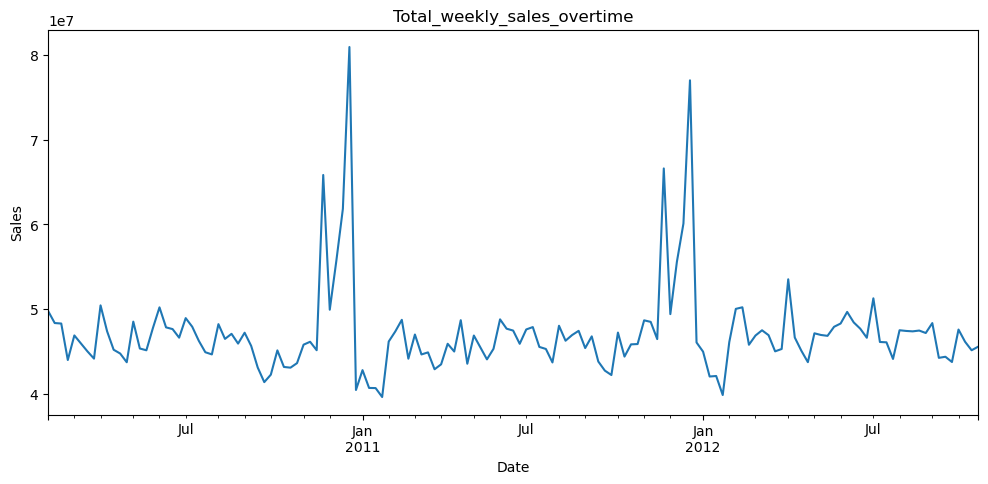

In [17]:
weekly_sales.plot(figsize=(12,5))
plt.title("Total_weekly_sales_overtime")
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [18]:
average_sales = train.groupby('IsHoliday')['Weekly_Sales'].mean()

In [19]:
average_sales.head()

IsHoliday
False    15901.649652
True     17036.092349
Name: Weekly_Sales, dtype: float64

In [20]:
train['year']=train['Date'].dt.year
train['month']=train['Date'].dt.month
train['Week']=train['Date'].dt.isocalendar().week

In [21]:
monthly_sales = train.groupby('month')['Weekly_Sales'].mean()

In [22]:
monthly_sales.info

<bound method Series.info of month
1     14126.220965
2     16008.947611
3     15416.956438
4     15650.483663
5     15776.455683
6     16326.231156
7     15861.613997
8     16062.717520
9     15096.249922
10    15244.132643
11    17491.151001
12    19356.052933
Name: Weekly_Sales, dtype: float64>

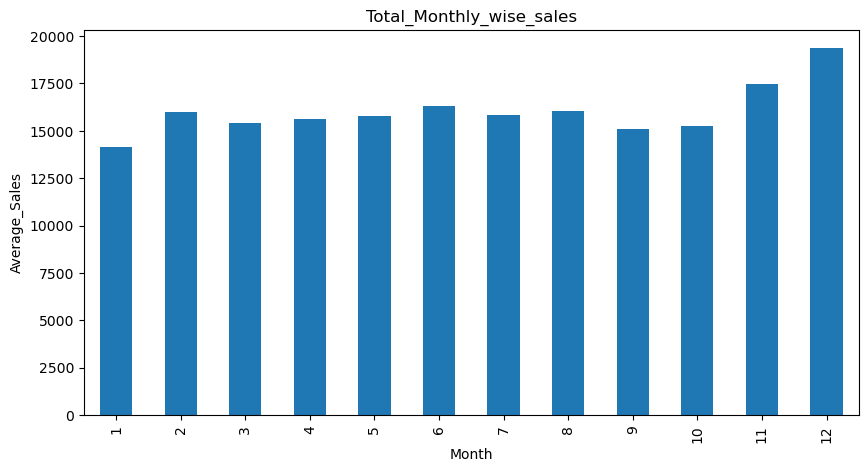

In [23]:
monthly_sales.plot(kind='bar',figsize=(10,5))
plt.title ("Total_Monthly_wise_sales")
plt.xlabel("Month")
plt.ylabel("Average_Sales")
plt.show()

In [24]:
store_sales = train.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending = False)
store_sales.head()

Store
20    3.014014e+08
4     2.995453e+08
14    2.890019e+08
13    2.865180e+08
2     2.753872e+08
Name: Weekly_Sales, dtype: float64

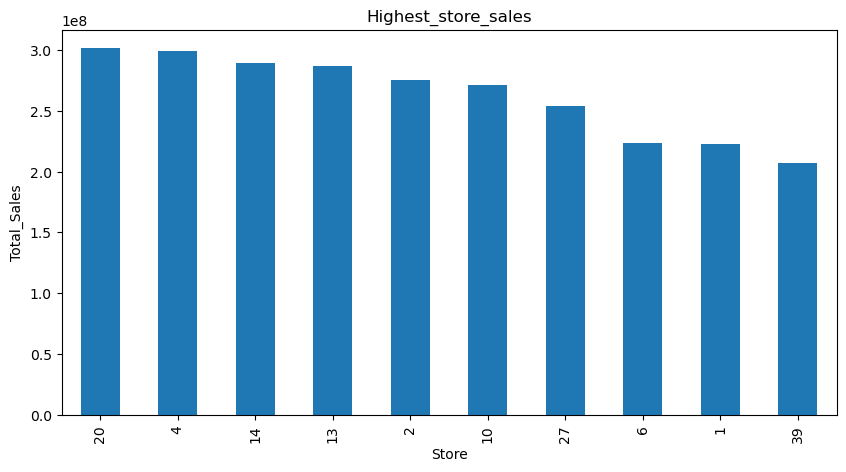

In [25]:
store_sales.head(10).plot(kind='bar',figsize=(10,5))
plt.title("Highest_store_sales")
plt.xlabel("Store")
plt.ylabel("Total_Sales")
plt.show()

In [26]:
store=pd.read_csv("C:/Users/91970/walmart-recruiting-store-sales-forecasting/Data/stores.csv")
store.info


<bound method DataFrame.info of     Store Type    Size
0       1    A  151315
1       2    A  202307
2       3    B   37392
3       4    A  205863
4       5    B   34875
5       6    A  202505
6       7    B   70713
7       8    A  155078
8       9    B  125833
9      10    B  126512
10     11    A  207499
11     12    B  112238
12     13    A  219622
13     14    A  200898
14     15    B  123737
15     16    B   57197
16     17    B   93188
17     18    B  120653
18     19    A  203819
19     20    A  203742
20     21    B  140167
21     22    B  119557
22     23    B  114533
23     24    A  203819
24     25    B  128107
25     26    A  152513
26     27    A  204184
27     28    A  206302
28     29    B   93638
29     30    C   42988
30     31    A  203750
31     32    A  203007
32     33    A   39690
33     34    A  158114
34     35    B  103681
35     36    A   39910
36     37    C   39910
37     38    C   39690
38     39    A  184109
39     40    A  155083
40     41    A  196321
41

In [27]:
sales_store = train.merge(store, on='Store')
sales_store.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,year,month,Week,Type,Size
0,1,1,2010-02-05,24924.50,False,2010,2,5,A,151315
1,1,1,2010-02-12,46039.49,True,2010,2,6,A,151315
2,1,1,2010-02-19,41595.55,False,2010,2,7,A,151315
3,1,1,2010-02-26,19403.54,False,2010,2,8,A,151315
4,1,1,2010-03-05,21827.90,False,2010,3,9,A,151315


In [28]:
store_sales = store_sales.reset_index()
store_sales.head()

,Store,Weekly_Sales
0,20,3.014014e+08
1,4,2.995453e+08
2,14,2.890019e+08
3,13,2.865180e+08
4,2,2.753872e+08


In [29]:
store_analysis = store_sales.merge(store,on='Store')
store_analysis.head()

,Store,Weekly_Sales,Type,Size
0,20,3.014014e+08,A,203742
1,4,2.995453e+08,A,205863
2,14,2.890019e+08,A,200898
3,13,2.865180e+08,A,219622
4,2,2.753872e+08,A,202307


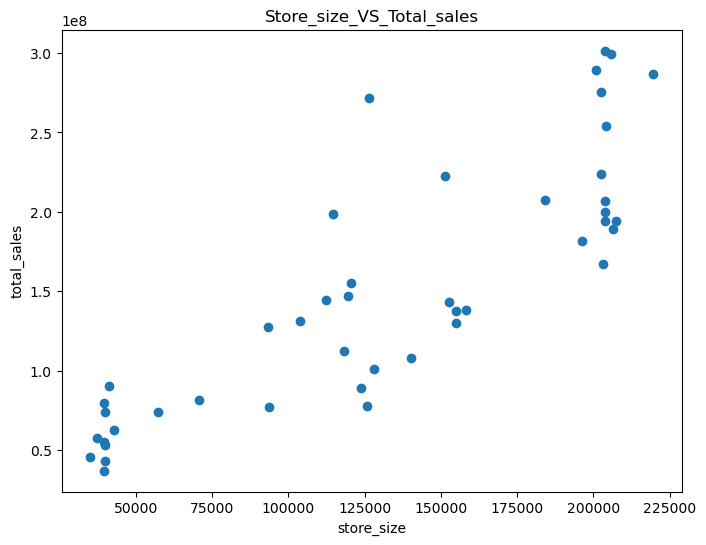

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(store_analysis['Size'],store_analysis['Weekly_Sales'])
plt.xlabel('store_size')
plt.ylabel('total_sales')
plt.title('Store_size_VS_Total_sales')
plt.show()

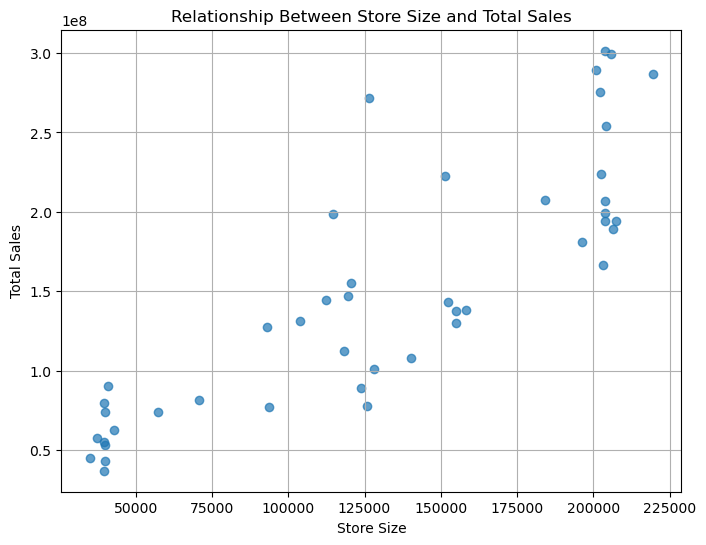

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(store_analysis['Size'], store_analysis['Weekly_Sales'], alpha=0.7)

plt.xlabel("Store Size")
plt.ylabel("Total Sales")
plt.title("Relationship Between Store Size and Total Sales")

plt.grid(True)

plt.show()

In [32]:
weekly_sales = train.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750875.98
1,2010-02-12,48336800.10
2,2010-02-19,48277902.33
3,2010-02-26,43970440.65
4,2010-03-05,46872715.16


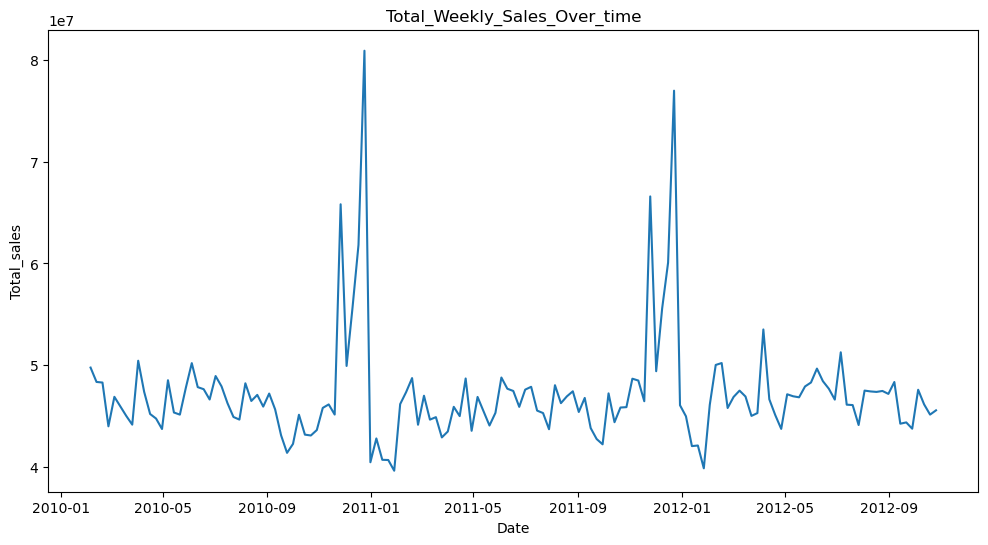

In [33]:
plt.figure(figsize=(12,6))
plt.plot(weekly_sales['Date'],weekly_sales['Weekly_Sales'])
plt.title('Total_Weekly_Sales_Over_time')
plt.xlabel('Date')
plt.ylabel('Total_sales')
plt.show()

In [34]:
weekly_sales_Sorted = weekly_sales.sort_values(by='Weekly_Sales', ascending=False)
weekly_sales_Sorted.head(10)

,Date,Weekly_Sales
46,2010-12-24,80931586.20
98,2011-12-23,76999773.57
94,2011-11-25,66593835.85
42,2010-11-26,65821216.26
45,2010-12-17,61821317.85
97,2011-12-16,60086723.16
44,2010-12-10,55667840.03
96,2011-12-09,55561557.73
113,2012-04-06,53502476.06
126,2012-07-06,51253625.62


In [35]:
weekly_sales_Sorted.head(10)['Date']

46    2010-12-24
98    2011-12-23
94    2011-11-25
42    2010-11-26
45    2010-12-17
97    2011-12-16
44    2010-12-10
96    2011-12-09
113   2012-04-06
126   2012-07-06
Name: Date, dtype: datetime64[ns]

In [36]:
forecast_data = weekly_sales.rename(columns={'Date':'ds','Weekly_Sales':'y'})
forecast_data.head()

,ds,y
0,2010-02-05,49750875.98
1,2010-02-12,48336800.10
2,2010-02-19,48277902.33
3,2010-02-26,43970440.65
4,2010-03-05,46872715.16


In [37]:
from prophet import Prophet
model = Prophet()

In [38]:
model.fit(forecast_data)

10:12:53 - cmdstanpy - INFO - Chain [1] start processing
10:12:54 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
future = model.make_future_dataframe(periods=8,freq='W')
future.tail()

,ds
146,2012-11-18
147,2012-11-25
148,2012-12-02
149,2012-12-09
150,2012-12-16


In [40]:
forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-02-05,4.708249e+07,4.306511e+07,5.219764e+07,4.708249e+07,4.708249e+07,7.146175e+05,7.146175e+05,7.146175e+05,7.146175e+05,7.146175e+05,7.146175e+05,0.0,0.0,0.0,4.779711e+07
1,2010-02-12,4.708193e+07,4.451427e+07,5.285306e+07,4.708193e+07,4.708193e+07,1.431980e+06,1.431980e+06,1.431980e+06,1.431980e+06,1.431980e+06,1.431980e+06,0.0,0.0,0.0,4.851391e+07
2,2010-02-19,4.708137e+07,4.255175e+07,5.163639e+07,4.708137e+07,4.708137e+07,5.422296e+04,5.422296e+04,5.422296e+04,5.422296e+04,5.422296e+04,5.422296e+04,0.0,0.0,0.0,4.713559e+07
3,2010-02-26,4.708080e+07,4.130004e+07,5.027552e+07,4.708080e+07,4.708080e+07,-1.161634e+06,-1.161634e+06,-1.161634e+06,-1.161634e+06,-1.161634e+06,-1.161634e+06,0.0,0.0,0.0,4.591917e+07
4,2010-03-05,4.708024e+07,4.125072e+07,4.986199e+07,4.708024e+07,4.708024e+07,-1.436966e+06,-1.436966e+06,-1.436966e+06,-1.436966e+06,-1.436966e+06,-1.436966e+06,0.0,0.0,0.0,4.564327e+07


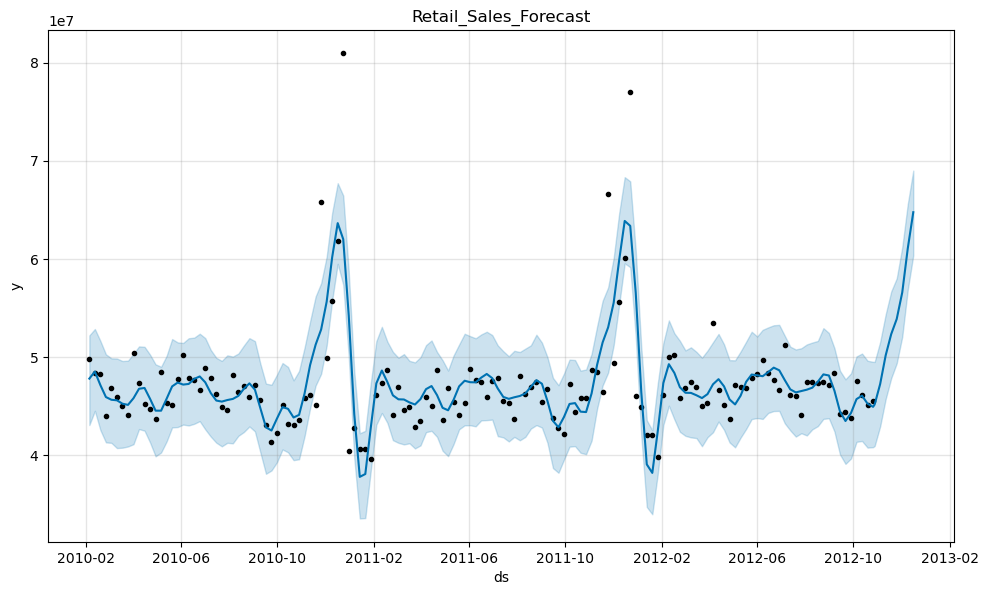

In [41]:
model.plot(forecast)
plt.title('Retail_Sales_Forecast')
plt.show()

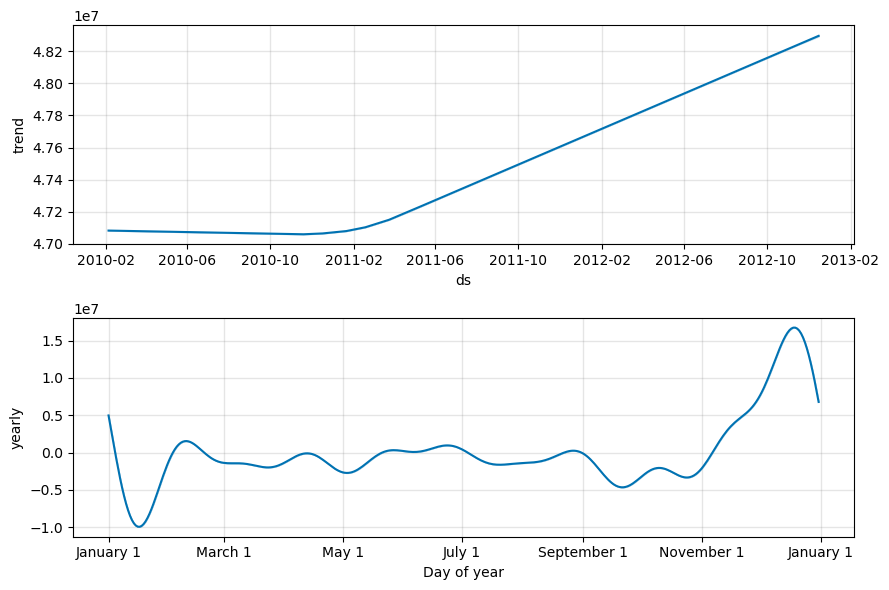

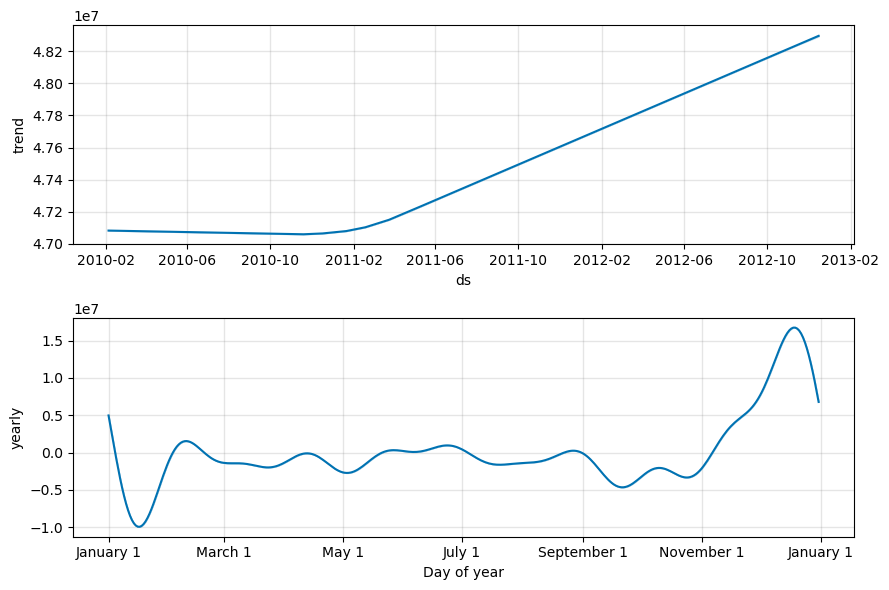

In [42]:
model.plot_components(forecast)

In [43]:
train_data = forecast_data[:-8]
test_data = forecast_data[-8:]

In [44]:
train_data.tail()
test_data

,ds,y
135,2012-09-07,48330449.03
136,2012-09-14,44226897.92
137,2012-09-21,44354937.08
138,2012-09-28,43735713.56
139,2012-10-05,47567053.49
140,2012-10-12,46128909.98
141,2012-10-19,45122443.96
142,2012-10-26,45544379.53


In [45]:
model = Prophet()
model.fit(train_data)

10:12:55 - cmdstanpy - INFO - Chain [1] start processing
10:12:56 - cmdstanpy - INFO - Chain [1] done processing


In [46]:
future = model.make_future_dataframe(periods=8,freq='W')
forecast=model.predict(future)

In [47]:
forecast[['ds','yhat']].tail(8)

,ds,yhat
135,2012-09-02,4.744329e+07
136,2012-09-09,4.550232e+07
137,2012-09-16,4.355712e+07
138,2012-09-23,4.313732e+07
139,2012-09-30,4.430876e+07
140,2012-10-07,4.553064e+07
141,2012-10-14,4.547138e+07
142,2012-10-21,4.466558e+07


In [48]:
test_data

,ds,y
135,2012-09-07,48330449.03
136,2012-09-14,44226897.92
137,2012-09-21,44354937.08
138,2012-09-28,43735713.56
139,2012-10-05,47567053.49
140,2012-10-12,46128909.98
141,2012-10-19,45122443.96
142,2012-10-26,45544379.53


In [49]:
from sklearn.metrics import mean_absolute_error

In [50]:
actual = test_data ['y'].values
predicted = forecast ['yhat'].tail(8).values
mae = mean_absolute_error(actual,predicted)
mae

1080385.8745757034

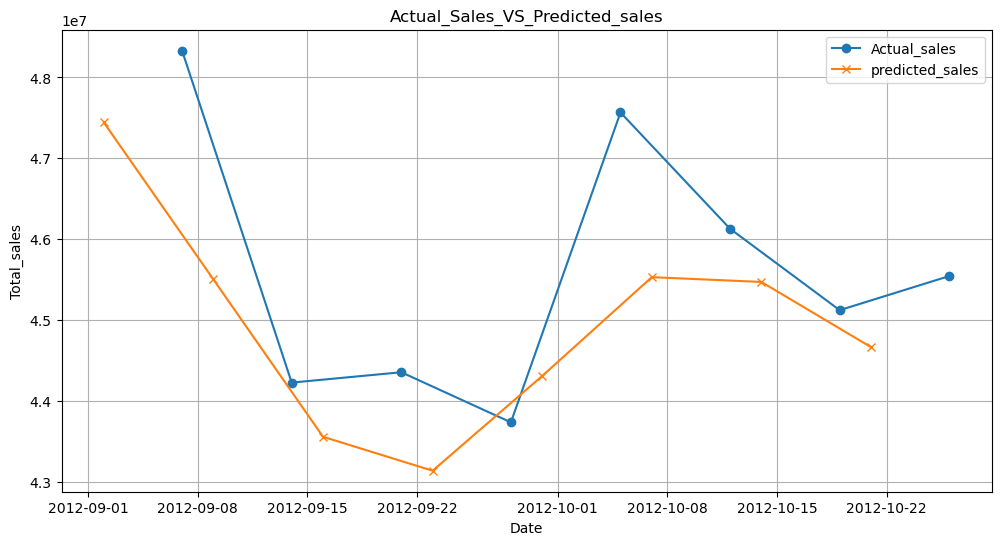

In [51]:
plt.figure(figsize=(12,6))
plt.plot(test_data['ds'],test_data['y'],label ='Actual_sales',marker='o')
plt.plot(forecast['ds'].tail(8),forecast['yhat'].tail(8),label ='predicted_sales',marker='x')
plt.title('Actual_Sales_VS_Predicted_sales')
plt.xlabel('Date')
plt.ylabel('Total_sales')
plt.legend()
plt.grid('True')
plt.show()

In [52]:
weekly_sales.to_csv("weekly_sales_cleaned.csv",index=False)

In [53]:
store_sales.to_csv("Store_sales_summary.csv",index=False)

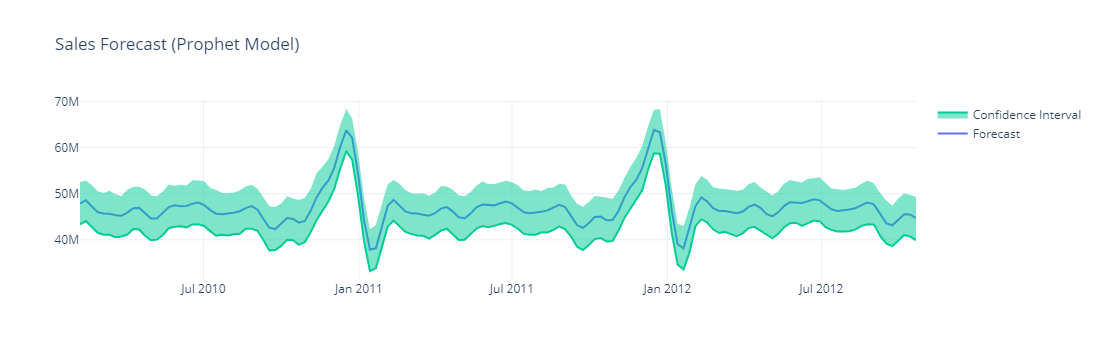

In [54]:
import plotly.graph_objects as go

df = forecast

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['ds'],
    y=df['yhat'],
    mode='lines',
    name='Forecast'
))

fig.add_trace(go.Scatter(
    x=df['ds'],
    y=df['yhat_upper'],
    line=dict(width=0),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=df['ds'],
    y=df['yhat_lower'],
    fill='tonexty',
    name='Confidence Interval'
))

fig.update_layout(
    title="Sales Forecast (Prophet Model)",
    template="plotly_white"
)

fig.show()

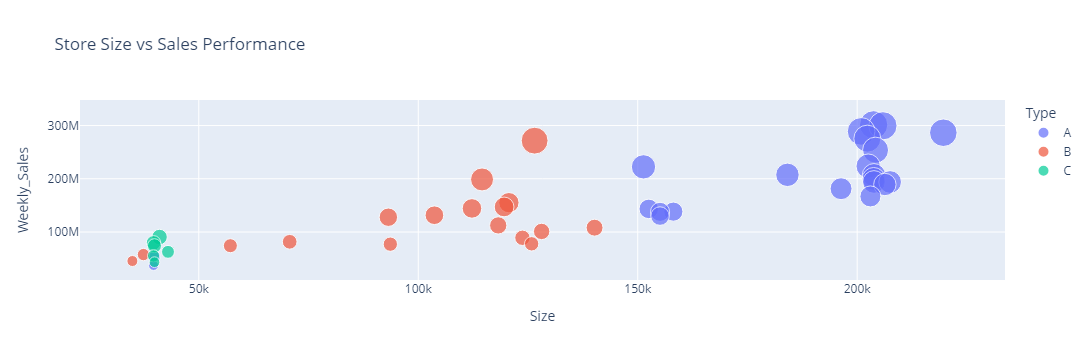

In [55]:
import plotly.express as px

fig = px.scatter(
    store_analysis,
    x='Size',
    y='Weekly_Sales',
    size='Weekly_Sales',
    color='Type',
    title='Store Size vs Sales Performance',
    hover_data=['Store']
)

fig.show()

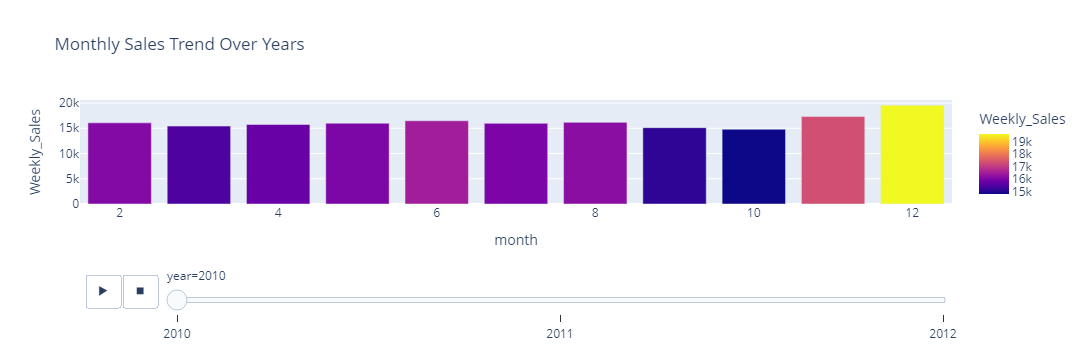

In [56]:
import plotly.express as px

monthly_sales = train.groupby(['year','month'])['Weekly_Sales'].mean().reset_index()

fig = px.bar(
    monthly_sales,
    x='month',
    y='Weekly_Sales',
    animation_frame='year',
    color='Weekly_Sales',
    title="Monthly Sales Trend Over Years"
)

fig.show()

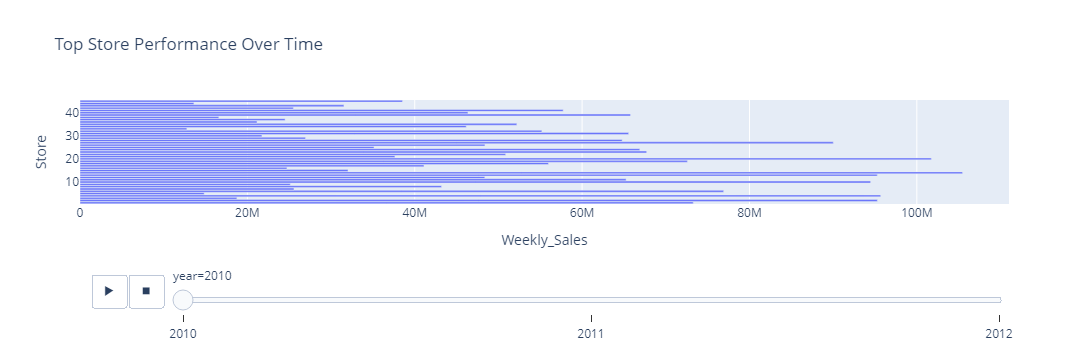

In [57]:
top_store = train.groupby(['Store','year'])['Weekly_Sales'].sum().reset_index()

import plotly.express as px

fig = px.bar(
    top_store,
    x='Weekly_Sales',
    y='Store',
    orientation='h',
    animation_frame='year',
    title='Top Store Performance Over Time'
)

fig.show()

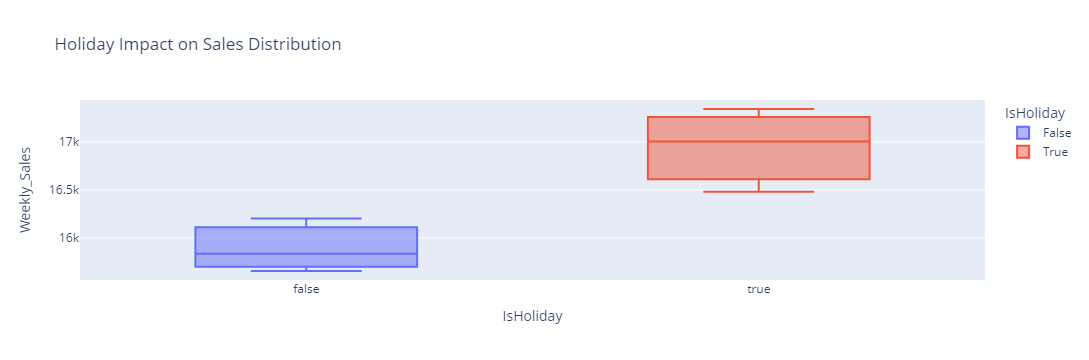

In [58]:
import plotly.express as px

holiday = train.groupby(['IsHoliday','year'])['Weekly_Sales'].mean().reset_index()

fig = px.box(
    holiday,
    x='IsHoliday',
    y='Weekly_Sales',
    color='IsHoliday',
    title="Holiday Impact on Sales Distribution"
)

fig.show()

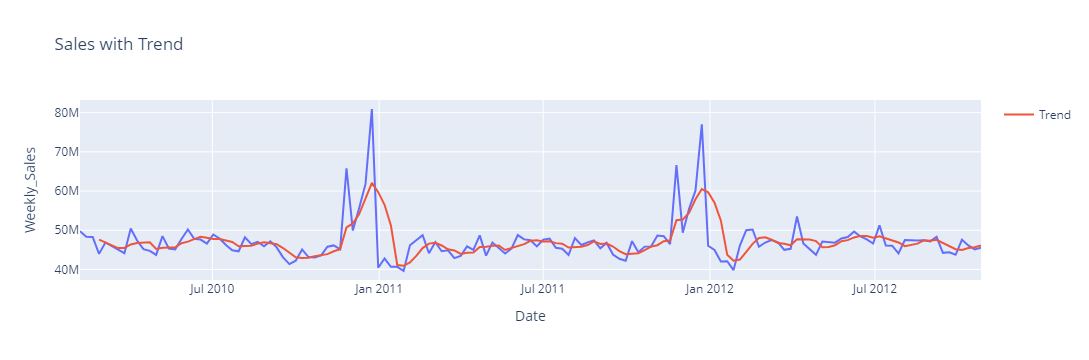

In [59]:
import plotly.express as px

weekly_sales['rolling'] = weekly_sales['Weekly_Sales'].rolling(4).mean()

fig = px.line(weekly_sales, x='Date', y='Weekly_Sales', title='Sales with Trend')

fig.add_scatter(
    x=weekly_sales['Date'],
    y=weekly_sales['rolling'],
    mode='lines',
    name='Trend'
)

fig.show()

In [60]:
import sys
print(sys.executable)

C:\Users\91970\anaconda3\python.exe
